


181/181 [==============================] - 1s 3ms/step


181/181 [==============================] - 0s 2ms/step


181/181 [==============================] - 0s 2ms/step
Final Accuracy Metrics:
OSD.longitude - Mean Squared Error: 8732.62, R-squared: 0.57%, Mean Absolute Error: 76.94, Variance Explained: 0.57%
OSD.latitude - Mean Squared Error: 8732.62, R-squared: 0.57%, Mean Absolute Error: 76.94, Variance Explained: 0.57%
OSD.height [ft] - Mean Squared Error: 8732.62, R-squared: 0.57%, Mean Absolute Error: 76.94, Variance Explained: 0.57%
OSD.pitch - Mean Squared Error: 8732.62, R-squared: 0.57%, Mean Absolute Error: 76.94, Variance Explained: 0.57%
OSD.roll - Mean Squared Error: 8732.62, R-squared: 0.57%, Mean Absolute Error: 76.94, Variance Explained: 0.57%
OSD.yaw - Mean Squared Error: 8732.62, R-squared: 0.57%, Mean Absolute Error: 76.94, Variance Explained: 0.57%
Total Training Data Points: 23079
31/31 [==============================] - 0s 2ms/step


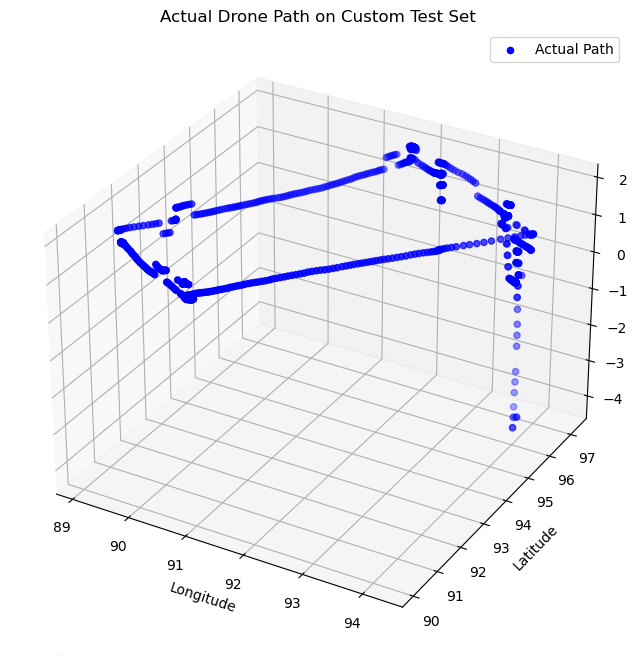

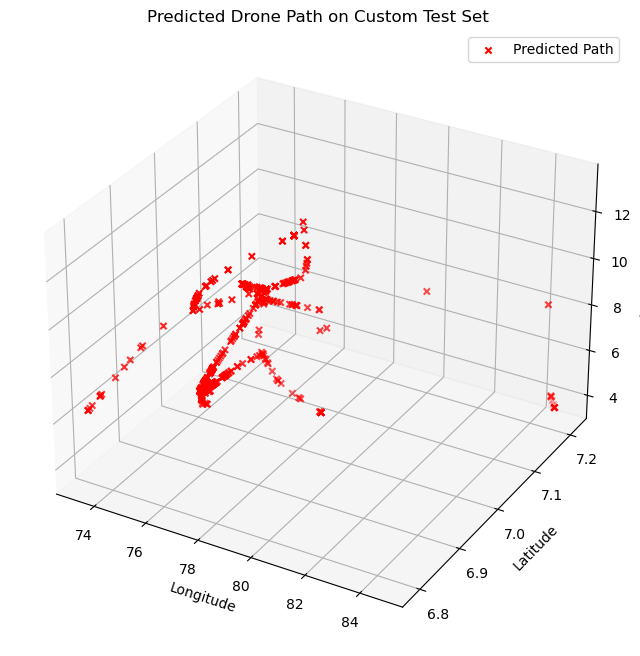

23079


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from tensorflow import keras
from tensorflow.keras import layers, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Assuming 'your_file.csv' is the name of your CSV file
training_folder = 'training'
testing_folder = 'testing'

# Read training data
training_files = [os.path.join(training_folder, file) for file in os.listdir(training_folder) if file.endswith('.csv')]
df_train = pd.concat([pd.read_csv(file) for file in training_files], ignore_index=True)

# Selecting relevant features and target variables
input_features = ['RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    df_train[input_features], df_train[output_targets], test_size=0.2, random_state=42
)

# Handling missing values in input features using SimpleImputer
imputer = SimpleImputer(strategy='mean')  
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Build a simpler neural network model
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(output_targets))
])

# Use a lower learning rate and add learning rate scheduling
lr_schedule = optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.0001,
    decay_steps=10000,
    decay_rate=0.9
)
optimizer = optimizers.Adam(learning_rate=lr_schedule)

# Compile the model
model.compile(optimizer=optimizer, loss='mean_squared_error')

# Implement early stopping and learning rate reduction on plateau
early_stopping = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=15, min_lr=1e-6)

# Train the model
total_training_data_points = X_train_scaled.shape[0]
for epoch in range(200):
    history = model.fit(X_train_scaled, y_train, epochs=1, batch_size=64, validation_split=0.2, callbacks=[early_stopping, reduce_lr], verbose=1)
    
    # Evaluate the model on the test set
    y_pred = model.predict(X_test_scaled)

# Calculate and display accuracy metrics for each target variable
for i, target_variable in enumerate(output_targets):
    mse = mean_squared_error(y_test[target_variable], y_pred[:, i])
    r2 = r2_score(y_test[target_variable], y_pred[:, i])
    mae = mean_absolute_error(y_test[target_variable], y_pred[:, i])
    variance_explained = 100 * (1 - mse / np.var(y_test[target_variable]))

# Print the final accuracy metrics and total training data points
print("Final Accuracy Metrics:")
for i, target_variable in enumerate(output_targets):
    print(f'{target_variable} - Mean Squared Error: {mse:.2f}, R-squared: {r2:.2%}, Mean Absolute Error: {mae:.2f}, Variance Explained: {variance_explained:.2f}%')

print(f'Total Training Data Points: {total_training_data_points}')

test_folder = 'testing'
test_files = [os.path.join(test_folder, file) for file in os.listdir(test_folder) if file.endswith('.csv')]
df_test_custom = pd.concat([pd.read_csv(file) for file in test_files], ignore_index=True)

# Handling missing values in input features using SimpleImputer
X_test_custom_imputed = imputer.transform(df_test_custom[input_features])

# Normalize the custom test data
X_test_custom_scaled = scaler.transform(X_test_custom_imputed)

# Make predictions on the custom test set
y_pred_custom = model.predict(X_test_custom_scaled)

# Create a 3D plot for the actual drone path on custom test set
fig_actual_custom = plt.figure(figsize=(12, 8))
ax_actual_custom = fig_actual_custom.add_subplot(111, projection='3d')
ax_actual_custom.scatter(df_test_custom['OSD.longitude'], df_test_custom['OSD.latitude'], df_test_custom['OSD.height [ft]'], c='blue', marker='o', label='Actual Path')
ax_actual_custom.set_xlabel('Longitude')
ax_actual_custom.set_ylabel('Latitude')
ax_actual_custom.set_zlabel('Altitude (ft)')
ax_actual_custom.set_title('Actual Drone Path on Custom Test Set')
ax_actual_custom.legend()

# Create a 3D plot for the predicted drone path on custom test set
fig_predicted_custom = plt.figure(figsize=(12, 8))
ax_predicted_custom = fig_predicted_custom.add_subplot(111, projection='3d')
ax_predicted_custom.scatter(y_pred_custom[:, 0], y_pred_custom[:, 1], y_pred_custom[:, 2], c='red', marker='x', label='Predicted Path')
ax_predicted_custom.set_xlabel('Longitude')
ax_predicted_custom.set_ylabel('Latitude')
ax_predicted_custom.set_zlabel('Altitude (ft)')
ax_predicted_custom.set_title('Predicted Drone Path on Custom Test Set')
ax_predicted_custom.legend()

# Show the actual and predicted path plots on the custom test set
plt.show()

print( X_train_scaled.shape[0])


# 15/02/2024

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from tensorflow import keras
from tensorflow.keras import layers, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Assuming 'your_file.csv' is the name of your CSV file
training_folder = 'training'
testing_folder = 'testing'

# Read training data
training_files = [os.path.join(training_folder, file) for file in os.listdir(training_folder) if file.endswith('.csv')]
df_train = pd.concat([pd.read_csv(file) for file in training_files], ignore_index=True)

# Selecting relevant features and target variables
input_features = ['OSD.flyTime','RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    df_train[input_features], df_train[output_targets], test_size=0.2, random_state=42
)

# Handling missing values in input features using SimpleImputer
imputer = SimpleImputer(strategy='mean')  
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Build a simpler neural network model
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(output_targets))
])

# Use a lower learning rate and add learning rate scheduling
lr_schedule = optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.0001,
    decay_steps=10000,
    decay_rate=0.9
)
optimizer = optimizers.Adam(learning_rate=lr_schedule)

# Compile the model
model.compile(optimizer=optimizer, loss='mean_squared_error')

# Implement early stopping and learning rate reduction on plateau
early_stopping = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=15, min_lr=1e-6)

# Train the model
history = model.fit(X_train_scaled, y_train, epochs=20, batch_size=64, validation_split=0.2, callbacks=[early_stopping, reduce_lr], verbose=1)

# Evaluate the model on the test set
y_pred = model.predict(X_test_scaled)

# Calculate and display accuracy metrics for each target variable
for i, target_variable in enumerate(output_targets):
    mse = mean_squared_error(y_test[target_variable], y_pred[:, i])
    r2 = r2_score(y_test[target_variable], y_pred[:, i])
    mae = mean_absolute_error(y_test[target_variable], y_pred[:, i])
    variance_explained = 100 * (1 - mse / np.var(y_test[target_variable]))
    
    print(f'{target_variable} - Mean Squared Error: {mse:.2f}, R-squared: {r2:.2%}, Mean Absolute Error: {mae:.2f}, Variance Explained: {variance_explained:.2f}%')

test_folder = 'testing'
test_files = [os.path.join(test_folder, file) for file in os.listdir(test_folder) if file.endswith('.csv')]
df_test_custom = pd.concat([pd.read_csv(file) for file in test_files], ignore_index=True)

# Handling missing values in input features using SimpleImputer
X_test_custom_imputed = imputer.transform(df_test_custom[input_features])

# Normalize the custom test data
X_test_custom_scaled = scaler.transform(X_test_custom_imputed)

# Make predictions on the custom test set
y_pred_custom = model.predict(X_test_custom_scaled)

# Create a 3D plot for the actual drone path on custom test set
fig_actual_custom = plt.figure(figsize=(12, 8))
ax_actual_custom = fig_actual_custom.add_subplot(111, projection='3d')
ax_actual_custom.scatter(df_test_custom['OSD.longitude'], df_test_custom['OSD.latitude'], df_test_custom['OSD.height [ft]'], c='blue', marker='o', label='Actual Path')
ax_actual_custom.set_xlabel('Longitude')
ax_actual_custom.set_ylabel('Latitude')
ax_actual_custom.set_zlabel('Altitude (ft)')
ax_actual_custom.set_title('Actual Drone Path on Custom Test Set')
ax_actual_custom.legend()

# Create a 3D plot for the predicted drone path on custom test set
fig_predicted_custom = plt.figure(figsize=(12, 8))
ax_predicted_custom = fig_predicted_custom.add_subplot(111, projection='3d')
ax_predicted_custom.scatter(y_pred_custom[:, 0], y_pred_custom[:, 1], y_pred_custom[:, 2], c='red', marker='x', label='Predicted Path')
ax_predicted_custom.set_xlabel('Longitude')
ax_predicted_custom.set_ylabel('Latitude')
ax_predicted_custom.set_zlabel('Altitude (ft)')
ax_predicted_custom.set_title('Predicted Drone Path on Custom Test Set')
ax_predicted_custom.legend()


# Show the actual and predicted path plots on the custom test set
plt.show()

print( X_train_scaled.shape[0])

ValueError: Cannot use mean strategy with non-numeric data:
could not convert string to float: '6m 6.8s'

Epoch 1/200
371/371 [==============================] - 2s 4ms/step - loss: 2622.5588 - val_loss: 2545.4922 - lr: 9.9611e-05
Epoch 2/200
371/371 [==============================] - 1s 3ms/step - loss: 2556.2976 - val_loss: 2442.5869 - lr: 9.9222e-05
Epoch 3/200
371/371 [==============================] - 1s 4ms/step - loss: 2406.5728 - val_loss: 2247.3635 - lr: 9.8835e-05
Epoch 4/200
371/371 [==============================] - 1s 4ms/step - loss: 2186.2429 - val_loss: 2005.0304 - lr: 9.8450e-05
Epoch 5/200
371/371 [==============================] - 1s 4ms/step - loss: 1962.5857 - val_loss: 1788.3905 - lr: 9.8066e-05
Epoch 6/200
371/371 [==============================] - 1s 3ms/step - loss: 1794.2216 - val_loss: 1650.4396 - lr: 9.7683e-05
Epoch 7/200
371/371 [==============================] - 1s 3ms/step - loss: 1707.1731 - val_loss: 1586.6018 - lr: 9.7302e-05
Epoch 8/200
371/371 [==============================] - 1s 3ms/step - loss: 1670.7893 - val_loss: 1556.9991 - lr: 9.6922e-05
Epoch 9/

371/371 [==============================] - 1s 3ms/step - loss: 1558.6179 - val_loss: 1473.3462 - lr: 5.9926e-05
Epoch 132/200
371/371 [==============================] - 1s 3ms/step - loss: 1557.8226 - val_loss: 1473.4773 - lr: 5.9693e-05
Epoch 133/200
371/371 [==============================] - 1s 3ms/step - loss: 1558.3015 - val_loss: 1473.4133 - lr: 5.9460e-05
Epoch 134/200
371/371 [==============================] - 1s 3ms/step - loss: 1558.8685 - val_loss: 1473.2905 - lr: 5.9228e-05
Epoch 135/200
371/371 [==============================] - 1s 3ms/step - loss: 1557.1812 - val_loss: 1473.2152 - lr: 5.8997e-05
Epoch 136/200
371/371 [==============================] - 1s 3ms/step - loss: 1558.8547 - val_loss: 1473.1190 - lr: 5.8767e-05
Epoch 137/200
371/371 [==============================] - 1s 3ms/step - loss: 1558.0989 - val_loss: 1473.3046 - lr: 5.8537e-05
Epoch 138/200
371/371 [==============================] - 1s 4ms/step - loss: 1559.1920 - val_loss: 1473.1754 - lr: 5.8309e-05
Epoch 

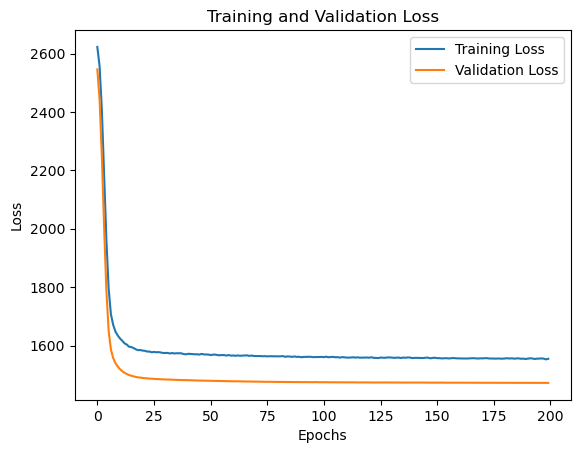

232/232 [==============================] - 1s 2ms/step
OSD.longitude - Mean Squared Error: 6.25, R-squared: -48880.43%, Mean Absolute Error: 2.24, Variance Explained: -48880.43%
OSD.latitude - Mean Squared Error: 0.03, R-squared: -61.98%, Mean Absolute Error: 0.09, Variance Explained: -61.98%
OSD.height [ft] - Mean Squared Error: 334.51, R-squared: 16.75%, Mean Absolute Error: 9.44, Variance Explained: 16.75%
OSD.pitch - Mean Squared Error: 8.48, R-squared: 28.30%, Mean Absolute Error: 1.84, Variance Explained: 28.30%
OSD.roll - Mean Squared Error: 3.28, R-squared: 1.31%, Mean Absolute Error: 1.16, Variance Explained: 1.31%
OSD.yaw - Mean Squared Error: 8590.63, R-squared: 0.40%, Mean Absolute Error: 76.24, Variance Explained: 0.40%


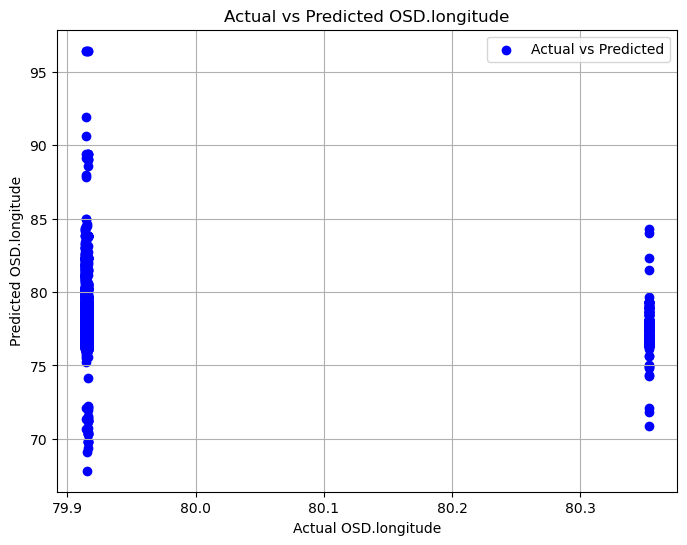

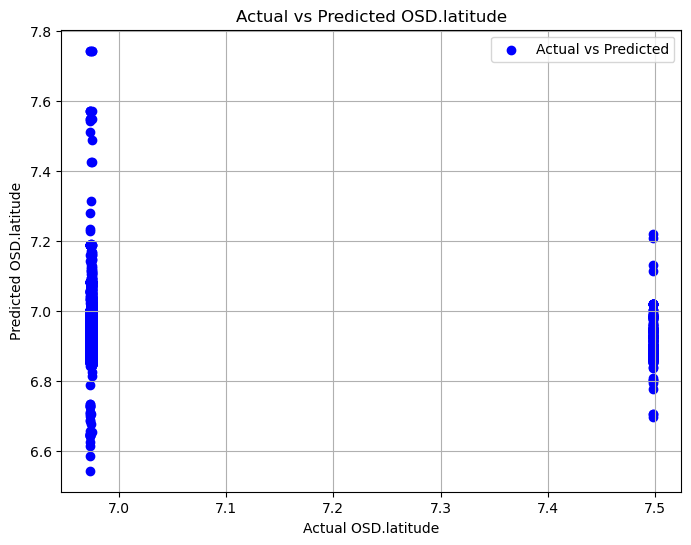

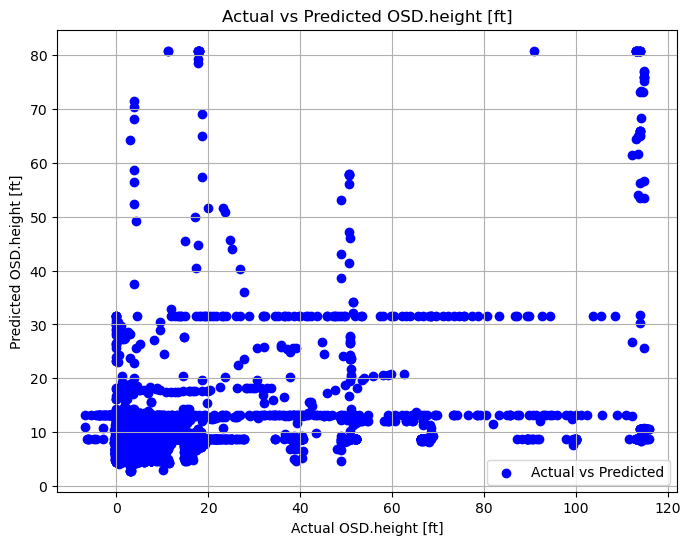

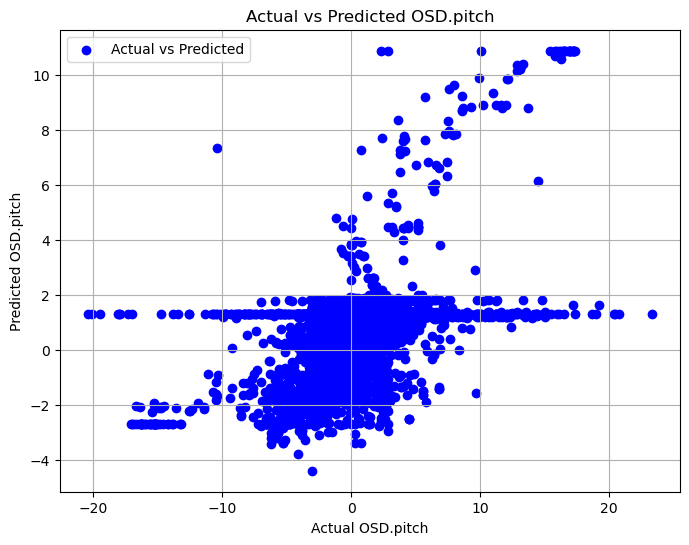

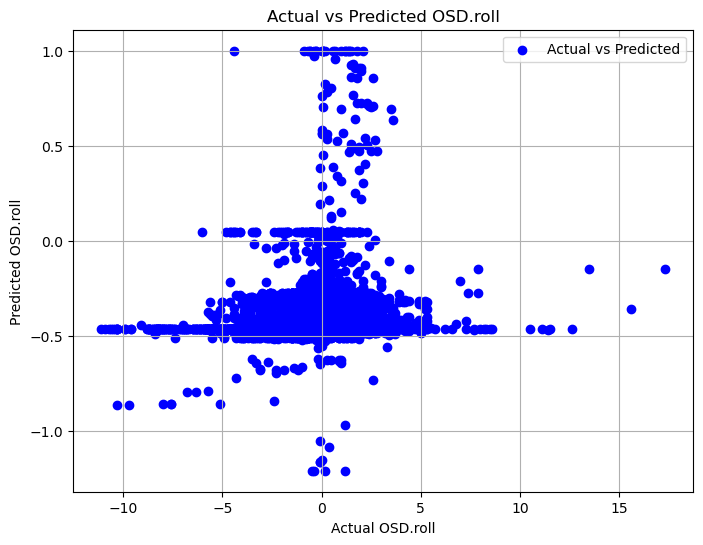

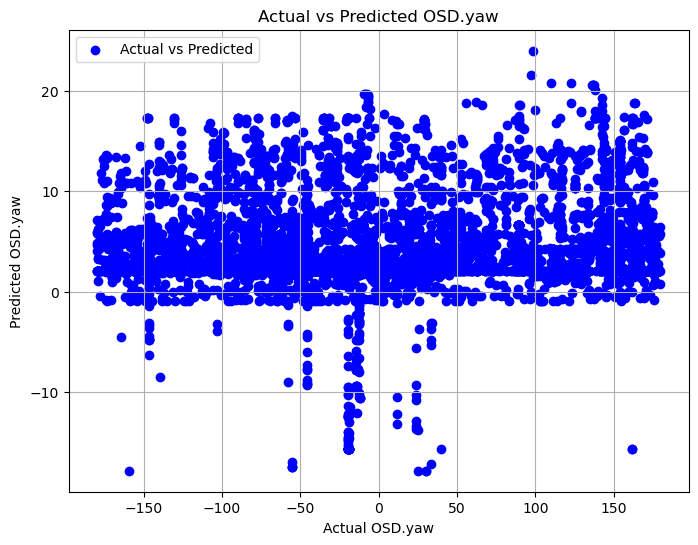

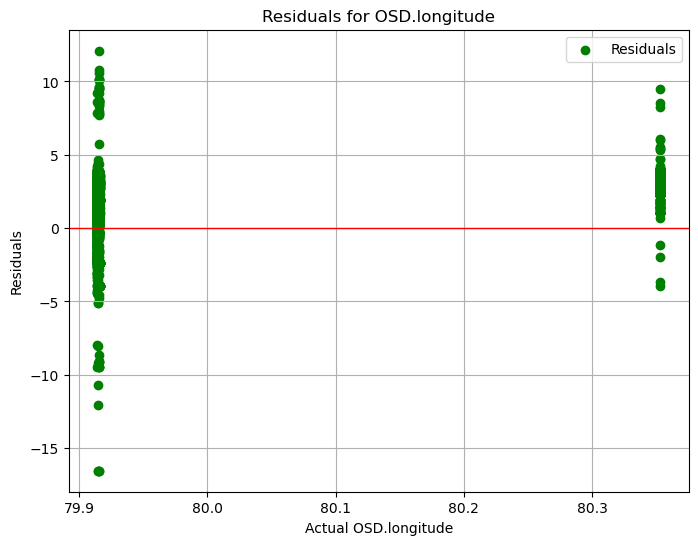

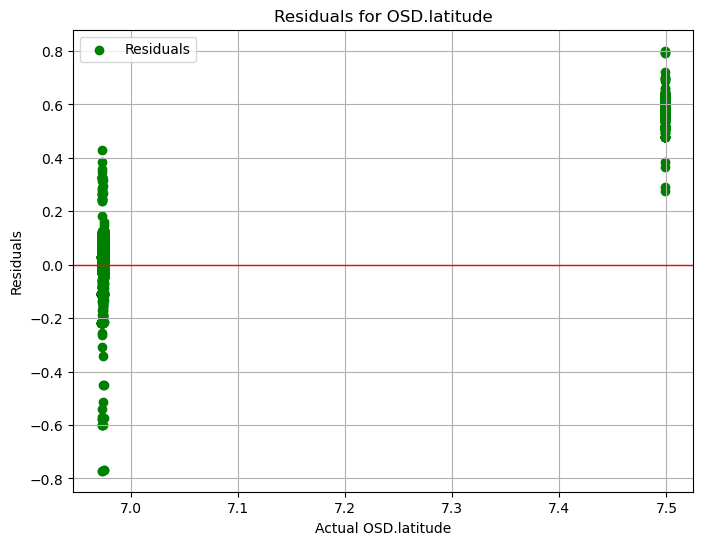

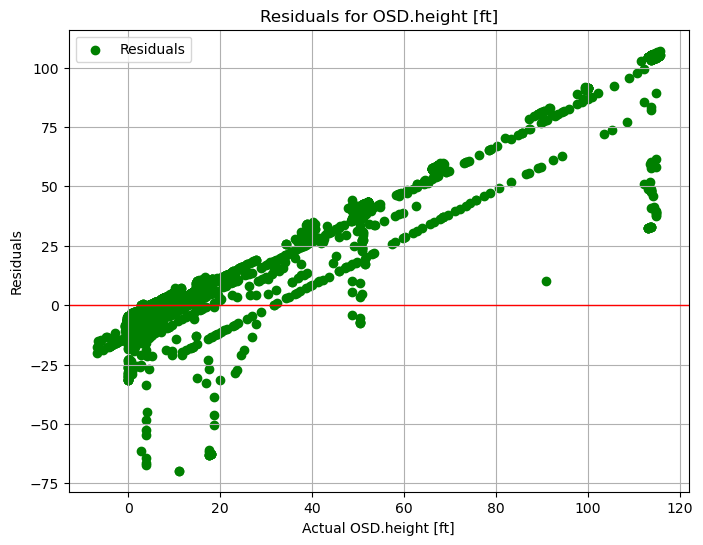

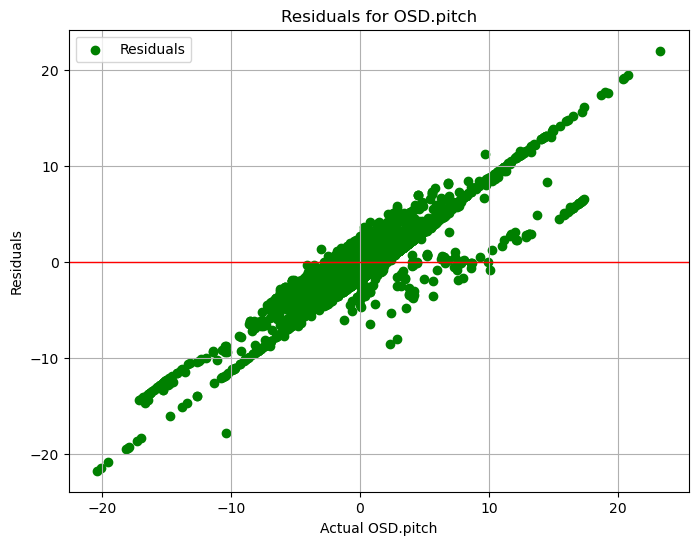

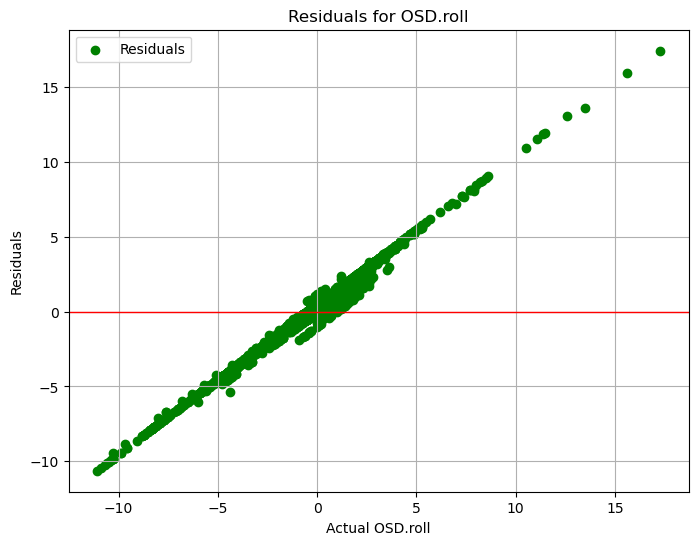

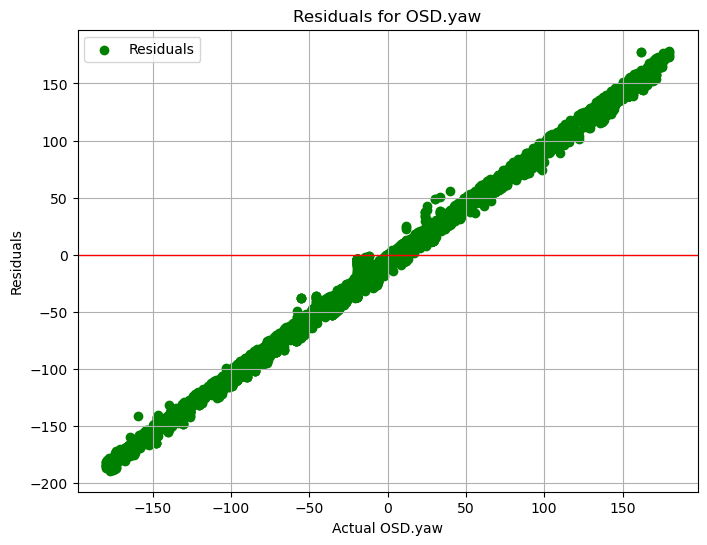

31/31 [==============================] - 0s 2ms/step


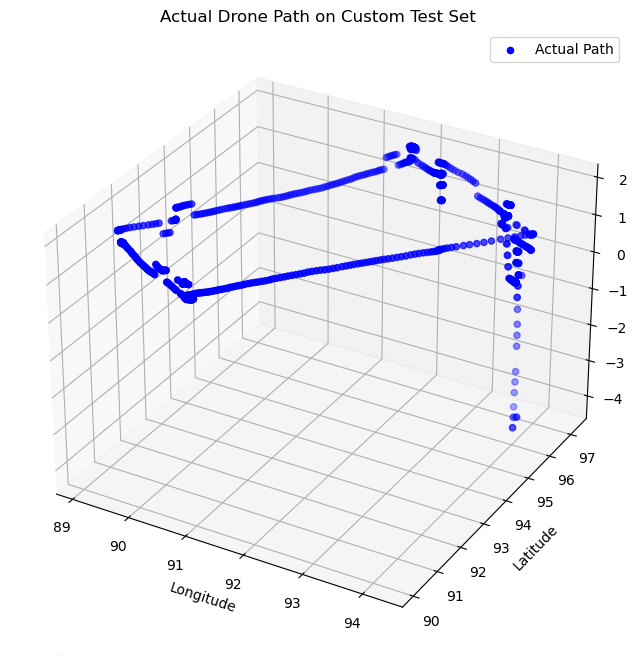

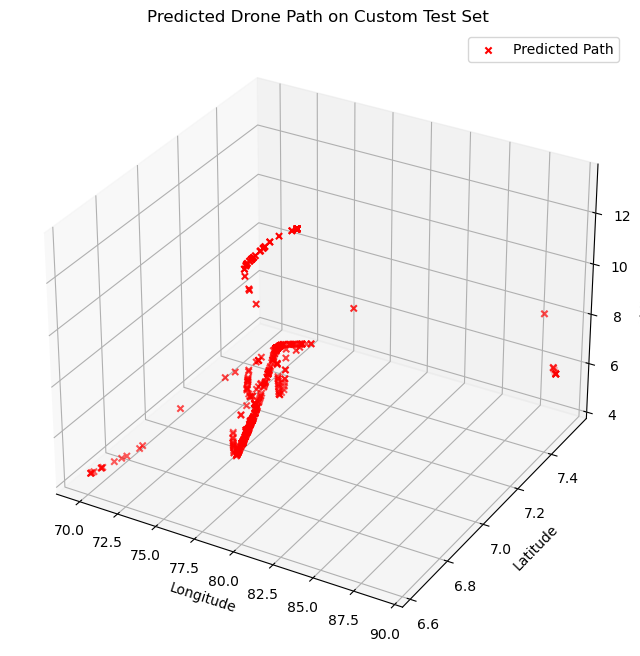

Total number of training samples: 29648


In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from tensorflow import keras
from tensorflow.keras import layers, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Assuming 'your_file.csv' is the name of your CSV file
training_folder = 'training'
testing_folder = 'testing'

# Read training data
training_files = [os.path.join(training_folder, file) for file in os.listdir(training_folder) if file.endswith('.csv')]
df_train = pd.concat([pd.read_csv(file) for file in training_files], ignore_index=True)

# Selecting relevant features and target variables
input_features = ['RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    df_train[input_features], df_train[output_targets], test_size=0.2, random_state=42
)

# Handling missing values in input features using SimpleImputer
imputer = SimpleImputer(strategy='mean')  
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Build a simpler neural network model
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(output_targets))
])

# Use a lower learning rate and add learning rate scheduling
lr_schedule = optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.0001,
    decay_steps=10000,
    decay_rate=0.9
)
optimizer = optimizers.Adam(learning_rate=lr_schedule)

# Compile the model
model.compile(optimizer=optimizer, loss='mean_squared_error')

# Implement early stopping and learning rate reduction on plateau
early_stopping = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=15, min_lr=1e-6)

# Train the model
history = model.fit(X_train_scaled, y_train, epochs=200, batch_size=64, validation_split=0.2, callbacks=[early_stopping, reduce_lr], verbose=1)

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Evaluate the model on the test set
y_pred = model.predict(X_test_scaled)

# Calculate and display accuracy metrics for each target variable
for i, target_variable in enumerate(output_targets):
    mse = mean_squared_error(y_test[target_variable], y_pred[:, i])
    r2 = r2_score(y_test[target_variable], y_pred[:, i])
    mae = mean_absolute_error(y_test[target_variable], y_pred[:, i])
    variance_explained = 100 * (1 - mse / np.var(y_test[target_variable]))
    
    print(f'{target_variable} - Mean Squared Error: {mse:.2f}, R-squared: {r2:.2%}, Mean Absolute Error: {mae:.2f}, Variance Explained: {variance_explained:.2f}%')

# Plotting actual vs predicted values for each target variable
for i, target_variable in enumerate(output_targets):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test[target_variable], y_pred[:, i], c='blue', marker='o', label='Actual vs Predicted')
    plt.xlabel('Actual ' + target_variable)
    plt.ylabel('Predicted ' + target_variable)
    plt.title('Actual vs Predicted ' + target_variable)
    plt.legend()
    plt.grid(True)
    plt.show()

# Plotting residuals for each target variable
for i, target_variable in enumerate(output_targets):
    residuals = y_test[target_variable] - y_pred[:, i]
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test[target_variable], residuals, c='green', marker='o', label='Residuals')
    plt.axhline(y=0, color='red', linestyle='-', linewidth=1)
    plt.xlabel('Actual ' + target_variable)
    plt.ylabel('Residuals')
    plt.title('Residuals for ' + target_variable)
    plt.legend()
    plt.grid(True)
    plt.show()

# Testing on custom data
test_folder = 'testing'
test_files = [os.path.join(test_folder, file) for file in os.listdir(test_folder) if file.endswith('.csv')]
df_test_custom = pd.concat([pd.read_csv(file) for file in test_files], ignore_index=True)

# Handling missing values in input features using SimpleImputer
X_test_custom_imputed = imputer.transform(df_test_custom[input_features])

# Normalize the custom test data
X_test_custom_scaled = scaler.transform(X_test_custom_imputed)

# Make predictions on the custom test set
y_pred_custom = model.predict(X_test_custom_scaled)

# Create a 3D plot for the actual drone path on custom test set
fig_actual_custom = plt.figure(figsize=(12, 8))
ax_actual_custom = fig_actual_custom.add_subplot(111, projection='3d')
ax_actual_custom.scatter(df_test_custom['OSD.longitude'], df_test_custom['OSD.latitude'], df_test_custom['OSD.height [ft]'], c='blue', marker='o', label='Actual Path')
ax_actual_custom.set_xlabel('Longitude')
ax_actual_custom.set_ylabel('Latitude')
ax_actual_custom.set_zlabel('Altitude (ft)')
ax_actual_custom.set_title('Actual Drone Path on Custom Test Set')
ax_actual_custom.legend()

# Create a 3D plot for the predicted drone path on custom test set
fig_predicted_custom = plt.figure(figsize=(12, 8))
ax_predicted_custom = fig_predicted_custom.add_subplot(111, projection='3d')
ax_predicted_custom.scatter(y_pred_custom[:, 0], y_pred_custom[:, 1], y_pred_custom[:, 2], c='red', marker='x', label='Predicted Path')
ax_predicted_custom.set_xlabel('Longitude')
ax_predicted_custom.set_ylabel('Latitude')
ax_predicted_custom.set_zlabel('Altitude (ft)')
ax_predicted_custom.set_title('Predicted Drone Path on Custom Test Set')
ax_predicted_custom.legend()

# Show the actual and predicted path plots on the custom test set
plt.show()

print(f'Total number of training samples: {X_train_scaled.shape[0]}')


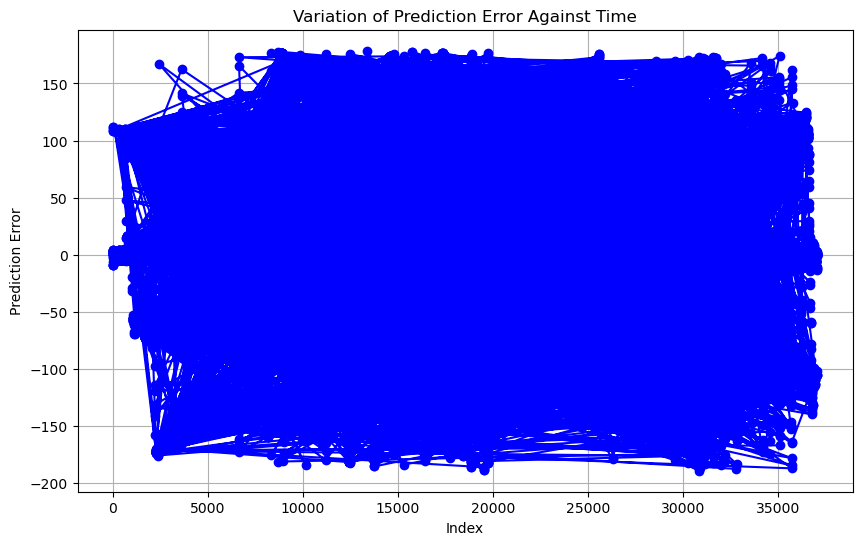

In [8]:
# Calculate residuals for each target variable
residuals_all = y_test - y_pred

# Plotting variation of prediction error against time (index)
plt.figure(figsize=(10, 6))
plt.plot(residuals_all.index, residuals_all, marker='o', linestyle='-', color='b')
plt.xlabel('Index')
plt.ylabel('Prediction Error')
plt.title('Variation of Prediction Error Against Time')
plt.grid(True)
plt.show()


Epoch 1/300
186/186 [==============================] - 3s 9ms/step - loss: 2623.4490 - val_loss: 2553.3574 - lr: 9.9805e-05
Epoch 2/300
186/186 [==============================] - 1s 5ms/step - loss: 2546.3396 - val_loss: 2392.3567 - lr: 9.9610e-05
Epoch 3/300
186/186 [==============================] - 1s 5ms/step - loss: 2261.4092 - val_loss: 1965.5217 - lr: 9.9415e-05
Epoch 4/300
186/186 [==============================] - 1s 5ms/step - loss: 1919.1804 - val_loss: 1688.8059 - lr: 9.9220e-05
Epoch 5/300
186/186 [==============================] - 1s 5ms/step - loss: 1803.5320 - val_loss: 1618.6362 - lr: 9.9026e-05
Epoch 6/300
186/186 [==============================] - 1s 5ms/step - loss: 1754.2543 - val_loss: 1586.6694 - lr: 9.8832e-05
Epoch 7/300
186/186 [==============================] - 1s 5ms/step - loss: 1736.5009 - val_loss: 1567.8899 - lr: 9.8639e-05
Epoch 8/300
186/186 [==============================] - 1s 6ms/step - loss: 1713.7546 - val_loss: 1552.4409 - lr: 9.8445e-05
Epoch 9/

186/186 [==============================] - 1s 5ms/step - loss: 1577.0293 - val_loss: 1485.0597 - lr: 7.7359e-05
Epoch 132/300
186/186 [==============================] - 1s 5ms/step - loss: 1576.3655 - val_loss: 1485.3297 - lr: 7.7208e-05
Epoch 133/300
186/186 [==============================] - 1s 5ms/step - loss: 1576.6058 - val_loss: 1484.7427 - lr: 7.7057e-05
Epoch 134/300
186/186 [==============================] - 1s 5ms/step - loss: 1576.5316 - val_loss: 1484.7780 - lr: 7.6906e-05
Epoch 135/300
186/186 [==============================] - 1s 5ms/step - loss: 1577.2925 - val_loss: 1485.2006 - lr: 7.6755e-05
Epoch 136/300
186/186 [==============================] - 1s 5ms/step - loss: 1576.3372 - val_loss: 1485.3135 - lr: 7.6605e-05
Epoch 137/300
186/186 [==============================] - 1s 5ms/step - loss: 1574.8330 - val_loss: 1484.1794 - lr: 7.6455e-05
Epoch 138/300
186/186 [==============================] - 1s 5ms/step - loss: 1577.6675 - val_loss: 1484.8403 - lr: 7.6305e-05
Epoch 

186/186 [==============================] - 1s 4ms/step - loss: 1559.9236 - val_loss: 1477.8125 - lr: 5.9961e-05
Epoch 262/300
186/186 [==============================] - 1s 4ms/step - loss: 1558.9822 - val_loss: 1477.7147 - lr: 5.9844e-05
Epoch 263/300
186/186 [==============================] - 1s 4ms/step - loss: 1560.7203 - val_loss: 1477.6119 - lr: 5.9727e-05
Epoch 264/300
186/186 [==============================] - 1s 4ms/step - loss: 1558.6993 - val_loss: 1477.5658 - lr: 5.9610e-05
Epoch 265/300
186/186 [==============================] - 1s 4ms/step - loss: 1561.5880 - val_loss: 1477.6887 - lr: 5.9493e-05
Epoch 266/300
186/186 [==============================] - 1s 4ms/step - loss: 1559.5046 - val_loss: 1477.6962 - lr: 5.9377e-05
Epoch 267/300
186/186 [==============================] - 1s 4ms/step - loss: 1558.8547 - val_loss: 1477.6084 - lr: 5.9260e-05
Epoch 268/300
186/186 [==============================] - 1s 4ms/step - loss: 1559.9576 - val_loss: 1477.4000 - lr: 5.9144e-05
Epoch 

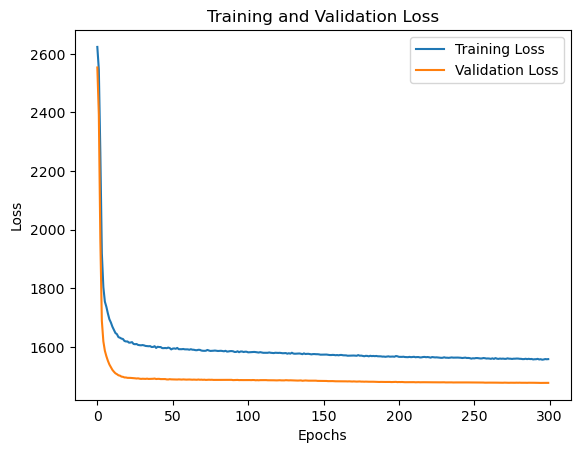

232/232 [==============================] - 1s 2ms/step
OSD.longitude - Mean Squared Error: 6.17, R-squared: -48279.57%, Mean Absolute Error: 2.41, Variance Explained: -48279.57%
OSD.latitude - Mean Squared Error: 0.03, R-squared: -74.09%, Mean Absolute Error: 0.11, Variance Explained: -74.09%
OSD.height [ft] - Mean Squared Error: 345.90, R-squared: 13.91%, Mean Absolute Error: 9.74, Variance Explained: 13.91%
OSD.pitch - Mean Squared Error: 9.18, R-squared: 22.35%, Mean Absolute Error: 1.92, Variance Explained: 22.35%
OSD.roll - Mean Squared Error: 3.28, R-squared: 1.10%, Mean Absolute Error: 1.16, Variance Explained: 1.10%
OSD.yaw - Mean Squared Error: 8603.46, R-squared: 0.25%, Mean Absolute Error: 76.23, Variance Explained: 0.25%


In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from tensorflow import keras
from tensorflow.keras import layers, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Assuming 'your_file.csv' is the name of your CSV file
training_folder = 'training'
testing_folder = 'testing'

# Read training data
training_files = [os.path.join(training_folder, file) for file in os.listdir(training_folder) if file.endswith('.csv')]
df_train = pd.concat([pd.read_csv(file) for file in training_files], ignore_index=True)

# Selecting relevant features and target variables
input_features = ['RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    df_train[input_features], df_train[output_targets], test_size=0.2, random_state=42
)

# Handling missing values in input features using SimpleImputer
imputer = SimpleImputer(strategy='mean')  
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Build a deeper neural network model
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(output_targets))
])

# Use a lower learning rate and add learning rate scheduling
lr_schedule = optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.0001,
    decay_steps=10000,
    decay_rate=0.9
)
optimizer = optimizers.Adam(learning_rate=lr_schedule)

# Compile the model
model.compile(optimizer=optimizer, loss='mean_squared_error')

# Implement early stopping and learning rate reduction on plateau
early_stopping = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=15, min_lr=1e-6)

# Train the model
history = model.fit(X_train_scaled, y_train, epochs=300, batch_size=128, validation_split=0.2, callbacks=[early_stopping, reduce_lr], verbose=1)

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Evaluate the model on the test set
y_pred = model.predict(X_test_scaled)

# Calculate and display accuracy metrics for each target variable
for i, target_variable in enumerate(output_targets):
    mse = mean_squared_error(y_test[target_variable], y_pred[:, i])
    r2 = r2_score(y_test[target_variable], y_pred[:, i])
    mae = mean_absolute_error(y_test[target_variable], y_pred[:, i])
    variance_explained = 100 * (1 - mse / np.var(y_test[target_variable]))
    
    print(f'{target_variable} - Mean Squared Error: {mse:.2f}, R-squared: {r2:.2%}, Mean Absolute Error: {mae:.2f}, Variance Explained: {variance_explained:.2f}%')
